In [6]:
# Importamos todas las librerias necesarias para mostrar y filtrar los datos correctamente
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Aplicamos el estilo de seaborn a los graficos y los mostramos dentro del notebook
sns.set_theme(style="whitegrid")
%matplotlib inline

In [7]:
# Usando la libreria pandas leemos el csv y lo guardamos en una variable para poder utilizarlo, luego mostramos que se ha cargado correctamente
df = pd.read_csv("pokemon.csv")
print(f"Dataset carregat: {df.shape[0]} files i {df.shape[1]} columnes.")

Dataset carregat: 1025 files i 15 columnes.


In [8]:
# Guardamos en una variable solo los pokemon que no son legendarios
df_normales = df[(df['is_legendary'] == False) & (df['is_mythical'] == False)]

In [32]:
# Obtenemos la fila del pokemon con mayor base_stat_total entre los no legendarios
idx_max = df_normales['base_stat_total'].idxmax()
mas_fuerte = df_normales.loc[[idx_max], ['name', 'base_stat_total']]

# Mostramos el resultado
mas_fuerte

,name,base_stat_total
288,Slaking,670


In [34]:
# Mostramos los 5 pokemon "normales" con mas puntos de fuerza
top_05_normales = (
    df_normales[['name', 'base_stat_total']]
    .sort_values(by='base_stat_total', ascending=False)  # Ordena de mayor a menor
    .head(5)                                            # Se queda con las 5 primeras filas
    .reset_index(drop=True)                              # Renumera el indice desde 0
)

# Mostramos el resultado
top_05_normales

,name,base_stat_total
0,Slaking,670
1,Hydreigon,600
2,Kommo-O,600
3,Goodra,600
4,Baxcalibur,600


In [36]:
# Agrupamos los pokemon "normales" por base_stat_total para ver cuantos comparten el mismo valor
escalones = (
    df_normales.groupby('base_stat_total').agg(cantidad=('name', 'count'),# Cuantos pokemon tienen ese valor                                    
    ejemplos=('name', lambda x: ', '.join(x.head(3))))                    # Hasta 3 nombres de ejemplo
    .reset_index()                                                        # Convierte base_stat_total de indice a columna
    .sort_values(by='base_stat_total', ascending=False)                   # Ordena de mayor a menor poder
    .reset_index(drop=True)                                               # Renumera el indice desde 0
)
# Mostramos los 15 escalones mas altos
escalones.head(15)

,base_stat_total,cantidad,ejemplos
0,670,1,Slaking
1,600,11,"Dragonite, Tyranitar, Salamence"
2,590,8,"Roaring-Moon, Iron-Valiant, Walking-Wake"
3,570,21,"Nihilego, Buzzwole, Pheromosa"
4,567,1,Archeops
5,555,1,Arcanine
6,552,1,Florges
7,550,4,"Volcarona, Ursaluna, Kingambit"
8,545,1,Togekiss
9,540,10,"Gyarados, Snorlax, Kingdra"


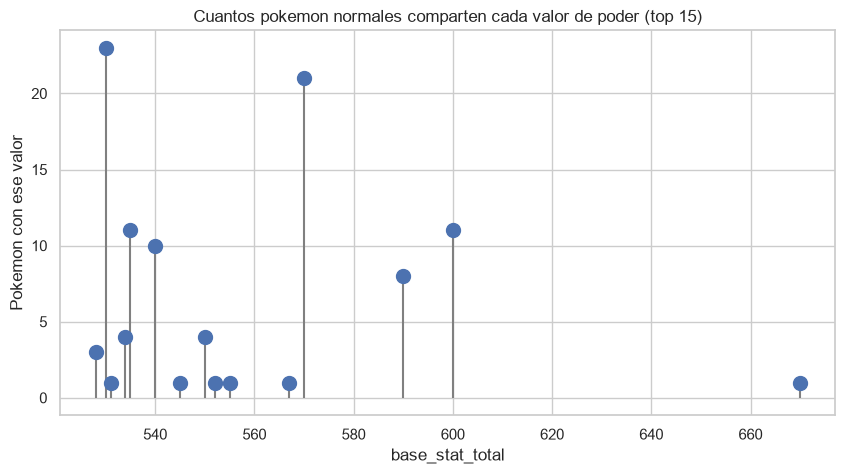

In [23]:
# Cogemos los 15 escalones mas altos del ranking
top_escalones = escalones.head(15)

# Dibujamos un palito por escalon: la altura es el numero de pokemon que comparten ese valor
plt.figure(figsize=(10, 5))
plt.vlines(x=top_escalones['base_stat_total'], ymin=0, ymax=top_escalones['cantidad'], color='gray')
plt.plot(top_escalones['base_stat_total'], top_escalones['cantidad'], 'o', markersize=10)
plt.xlabel('base_stat_total')
plt.ylabel('Pokemon con ese valor')
plt.title('Cuantos pokemon normales comparten cada valor de poder (top 15)')
plt.show()